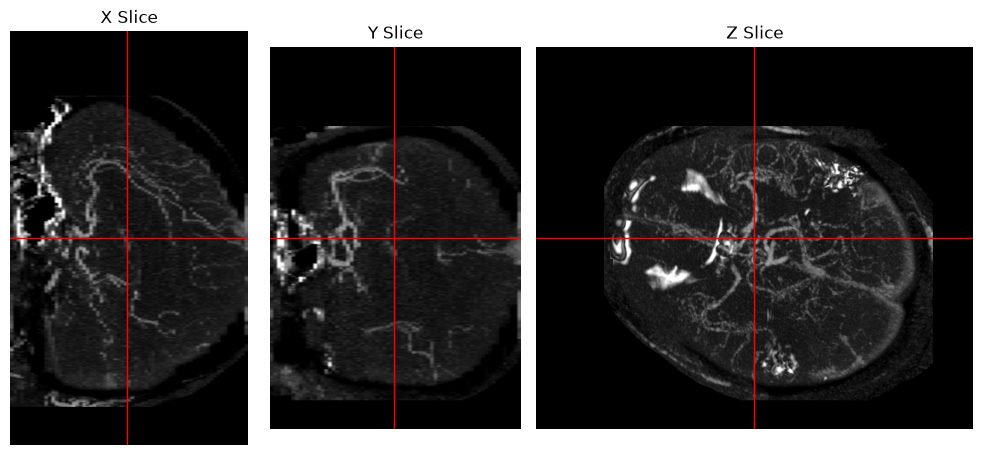

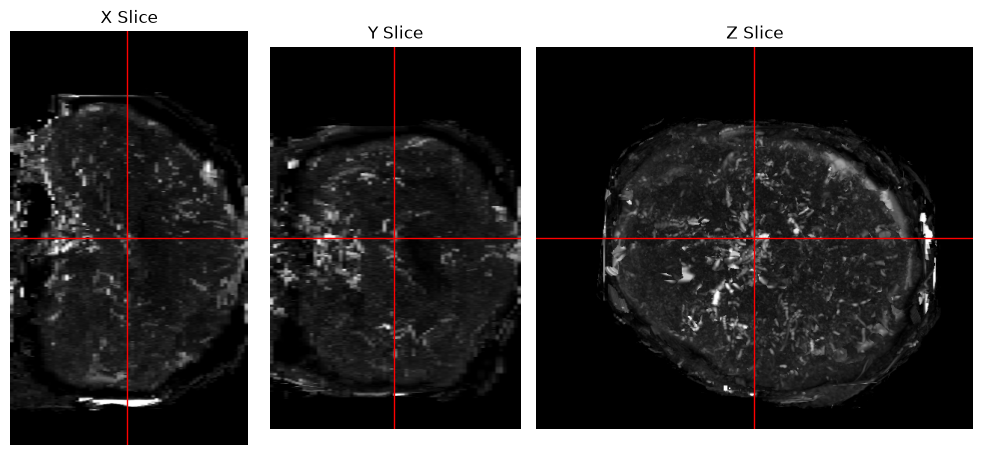

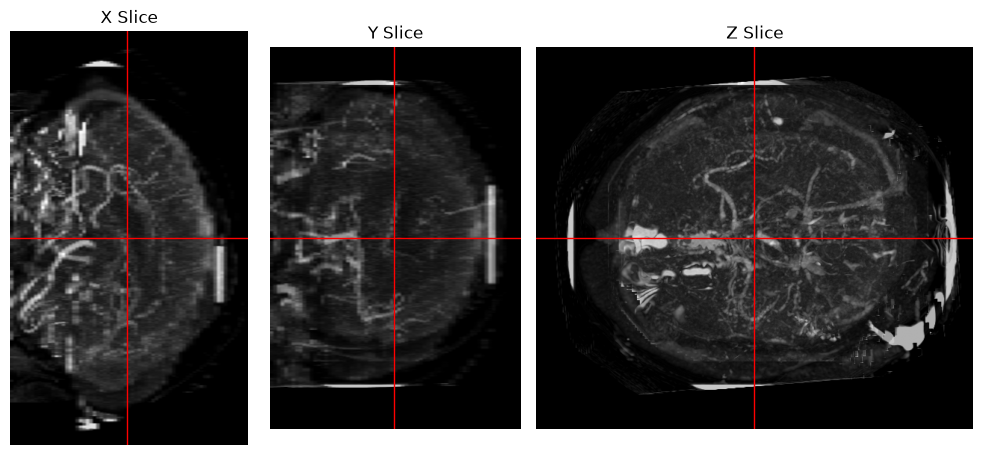

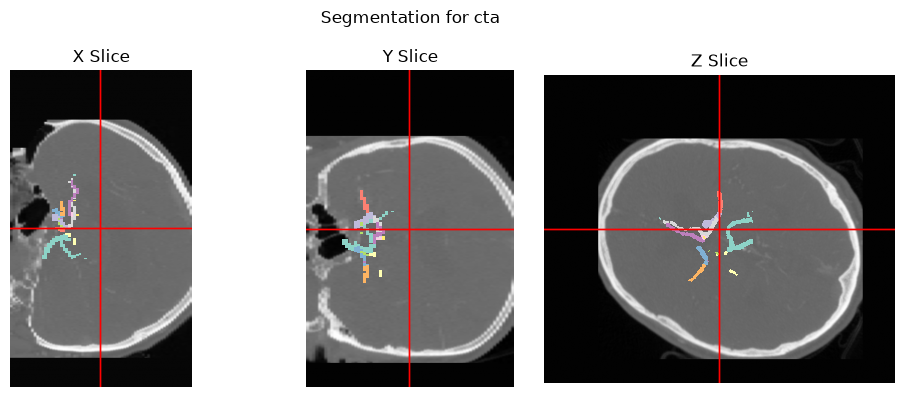

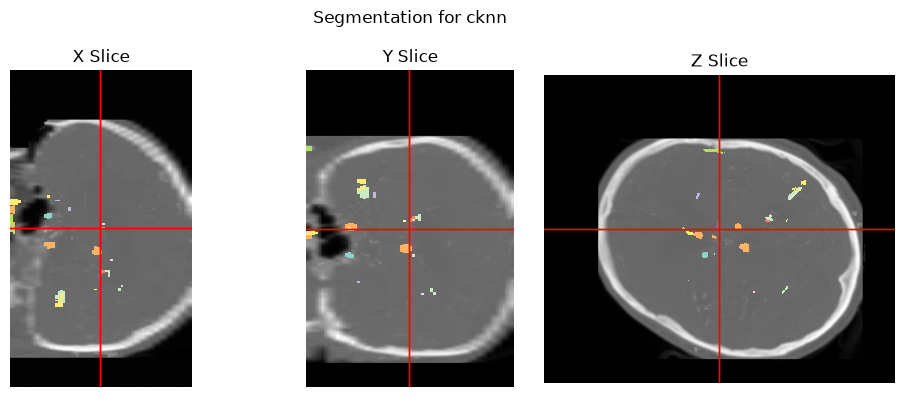

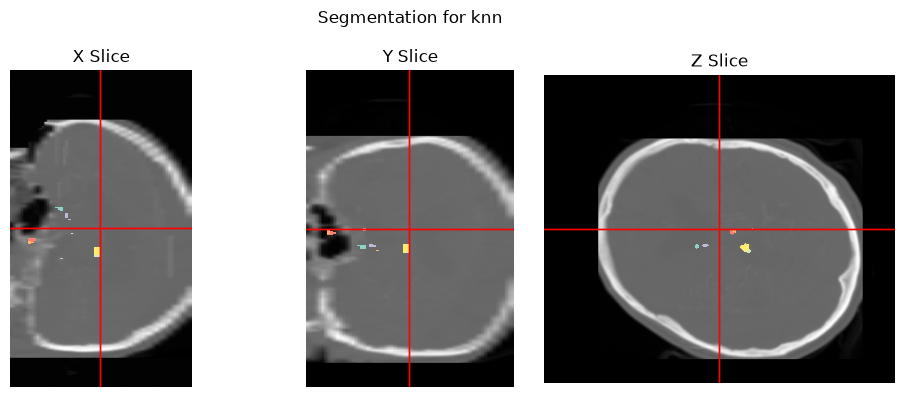

In [4]:
import sys
sys.path.append("../scripts/")
sys.path.append("../")

from scripts.plots import plot_cta_and_segmentation, plot_from_path
import matplotlib.pyplot as plt

pred_path = "../nnUNet_raw/Predictions_val_small/"
pred_path_norm = "../nnUNet_raw/Predictions_val/"
data_path_norm = "../nnUNet_raw/Dataset_val/"

case_channel = {"cta": ("0001","0001"),
                #"ncct": ("0000","0000"), 
                "cknn": ("0001","0001"),
                "knn": ("0001","0001")}


id_no = 7
id_no = str(id_no).zfill(4)

# First print the vessel structures
for case, channel in case_channel.items():
    
    if case == "cta":
        path = f"{data_path_norm}/labelsVl/case_{id_no}_{channel[0]}.nii.gz"
    else:
        path = f"{pred_path_norm}/images_{case}/case_{id_no}_{channel[0]}.nii.gz"
    fig = plot_from_path(
        path=path,
        slices = (0.5, 0.5, 0.5),
        thicknesses = (20, 20, 20),
        cmap = "gray",
    )
    plt.tight_layout()
    plt.gcf().savefig(f"../figures/vessel_{id_no}_{case}.png", dpi=300)

# Then print the secmentation results
for case, channel in case_channel.items():    
    fig = plot_cta_and_segmentation(
        input_case_path=f"{pred_path}/images_{case}/case_{id_no}_{channel[0]}.nii.gz",
        prediction_case_path=f"{pred_path}/segment_{case}/case_{id_no}_{channel[1]}.nii.gz",
        slices = (0.5, 0.5, 0.5),
        thickness = (1, 1, 1),
        figsize=(10, 4)
    )
    plt.suptitle(f"Segmentation for {case}")
    plt.tight_layout()
    plt.gcf().savefig(f"../figures/segmentation_{id_no}_{case}.png", dpi=300)